In [1]:
import mudata as md
import matplotlib.pyplot as plt
import numpy as np
import torch
import pandas as pd
import seaborn as sns
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, TraceEnum_ELBO, config_enumerate, infer_discrete
from pyro.optim import Adam
from pyro import poutine
from pyro.infer.autoguide import AutoNormal
import sys

/Users/ljb80/mambaforge/envs/pyro/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
adata = md.read("/Users/ljb80/Data/PapalexiSatija2021_eccite_RNA.h5ad")
adata

AnnData object with n_obs × n_vars = 20729 × 18649
    obs: 'hto', 'guide_id', 'hto_barcode', 'gdo_barcode', 'perturbation', 'tissue_type', 'cell_line', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo'
    var: 'ensembl_id', 'ncounts', 'ncells'

In [3]:
gdata = md.AnnData(pd.get_dummies(adata.obs["perturbation"]))
gdata

AnnData object with n_obs × n_vars = 20729 × 99

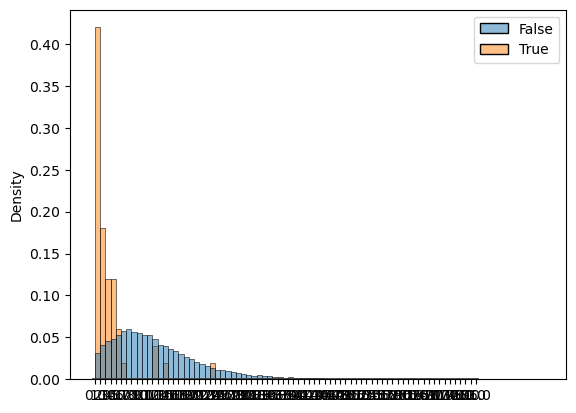

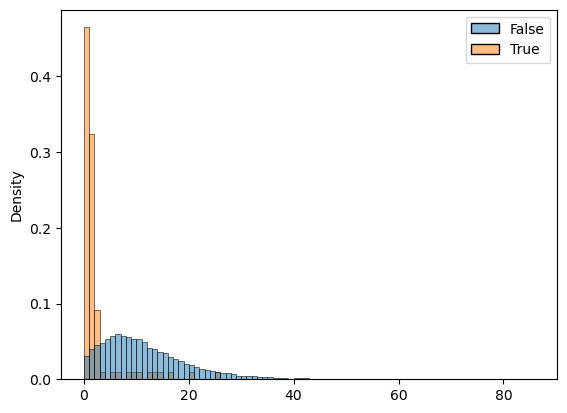

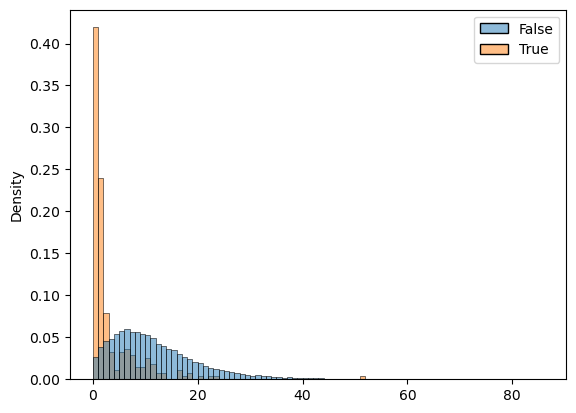

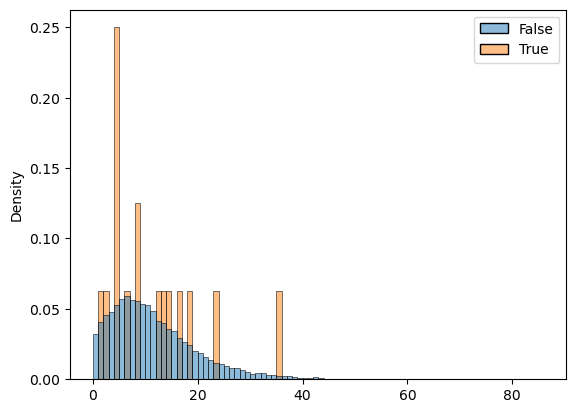

In [4]:

sns.violinplot(x=adata[:,"STAT1"].X.todense().A1, y=adata.obs["guide_id"].str.contains("control").values.squeeze())
counts = adata[:, "STAT1"].X.todense().A1
for i in range(1,5):
    perts = adata.obs["guide_id"].str.contains(f"STAT1g{i}").values
    sns.histplot(x=counts, hue=perts, common_norm=False, stat="density", binwidth=1)
    plt.show()

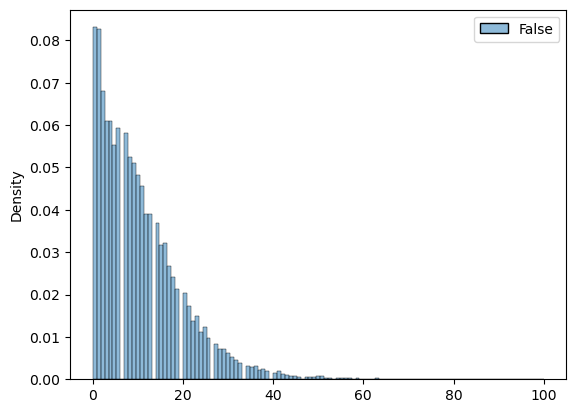

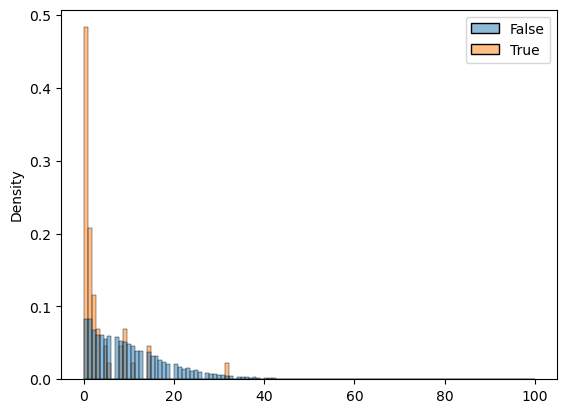

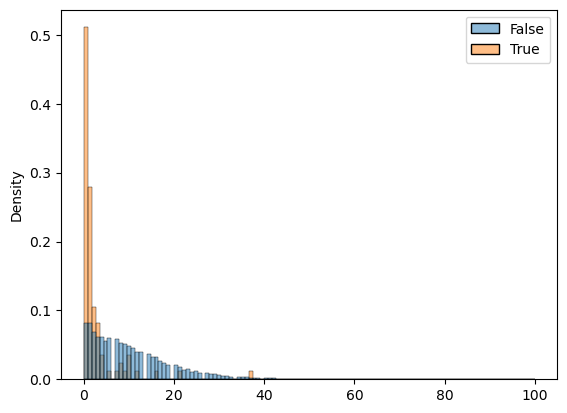

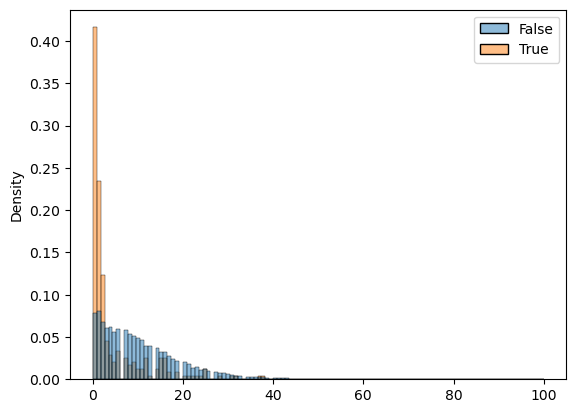

In [5]:
import seaborn as sns

# sns.violinplot(x=adata[:,"STAT1"].X.todense().squeeze(), y=adata.obs["guide_id"].str.contains("STAT1").values.squeeze())
counts = adata[:, "IRF1"].X.todense().A1
for i in range(4):
    perts = adata.obs["guide_id"].str.contains(f"STAT1g{i}").values
    sns.histplot(x=counts, hue=perts, common_norm=False, stat="density")
    plt.show()

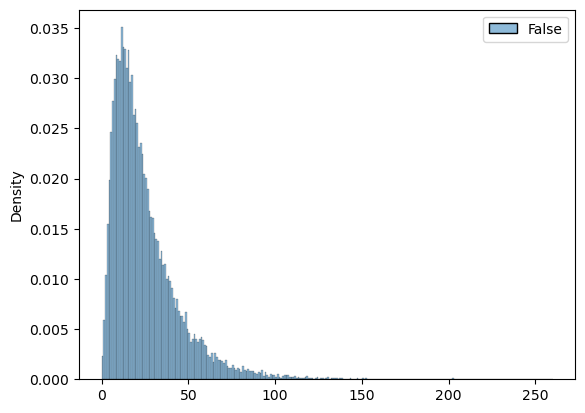

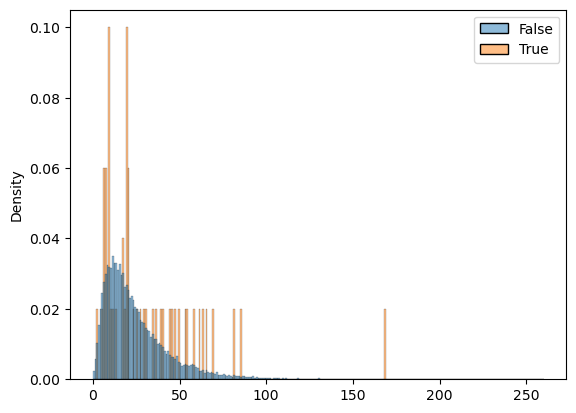

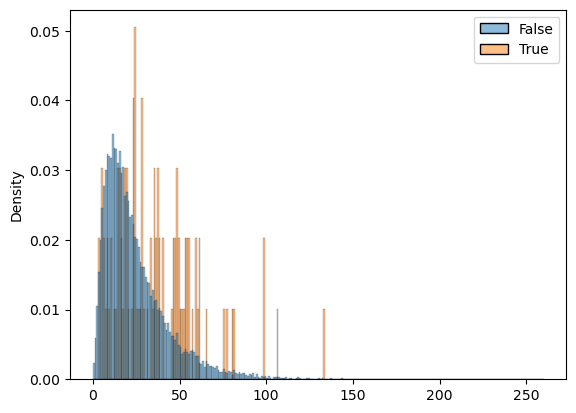

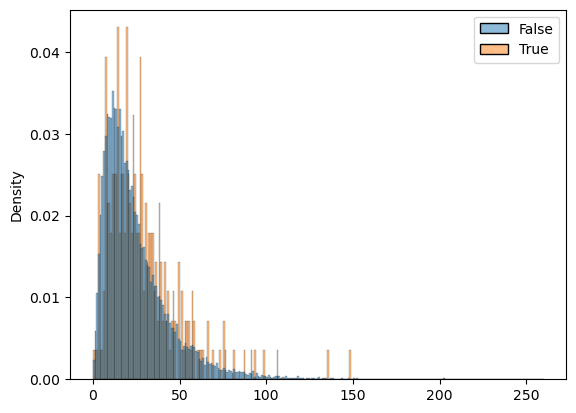

In [6]:
import seaborn as sns

# sns.violinplot(x=adata[:,"STAT1"].X.todense().squeeze(), y=adata.obs["guide_id"].str.contains("STAT1").values.squeeze())
counts = adata[:, "GAPDH"].X.todense().A1
for i in range(4):
    perts = adata.obs["guide_id"].str.contains(f"STAT1g{i}").values
    sns.histplot(x=counts, hue=perts, common_norm=False, stat="density", binwidth=1)
    plt.show()

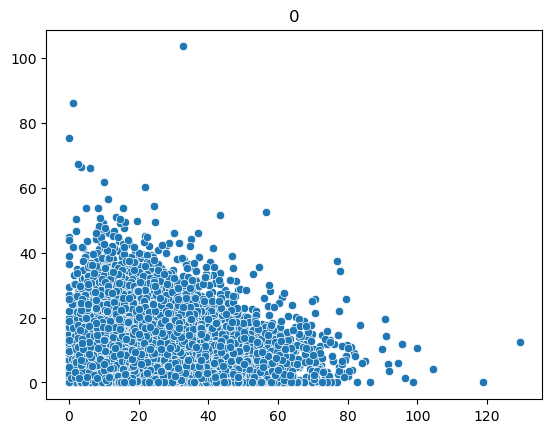

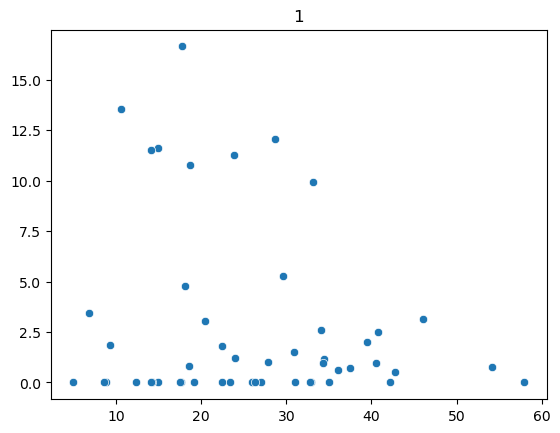

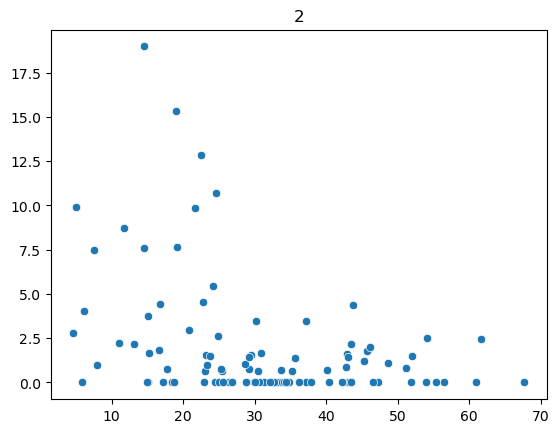

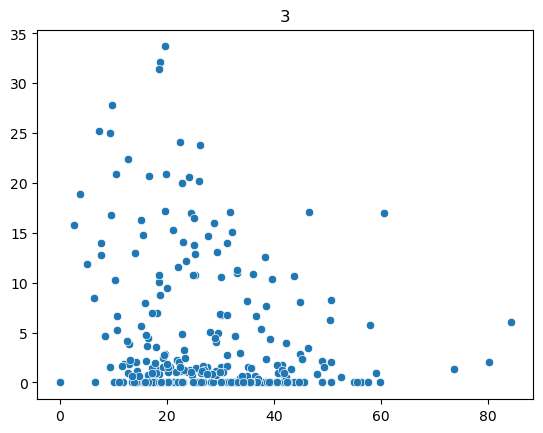

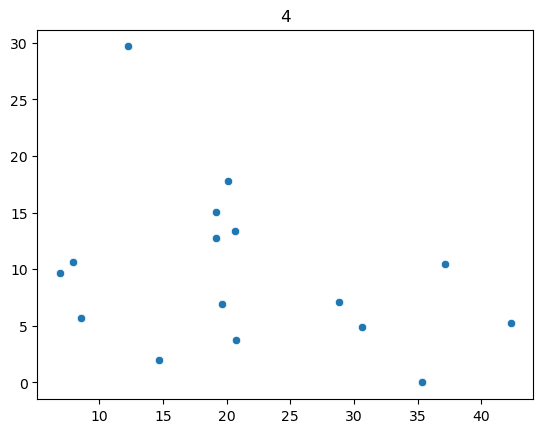

In [7]:
import seaborn as sns

# sns.violinplot(x=adata[:,"STAT1"].X.todense().squeeze(), y=adata.obs["guide_id"].str.contains("STAT1").values.squeeze())
trans_counts = adata[:, "IRF1"].X.todense().A1
lib_size = adata.X.sum(axis=1).A1
size_factor = lib_size / lib_size.mean()
for i in range(5):
    if i == 0:
        perts = ~adata.obs["guide_id"].str.contains(f"control").values
        sns.scatterplot(x=counts[perts] / size_factor[perts], y=trans_counts[perts] / size_factor[perts])
    else:
        perts = adata.obs["guide_id"].str.contains(f"STAT1g{i}").values
        sns.scatterplot(x=counts[perts] / size_factor[perts], y=trans_counts[perts] / size_factor[perts])
    plt.title(i)
    plt.show()

In [8]:
selected_genes = ["STAT1", "STAT2", "IRF1", "ACTB", "GAPDH"]
selected_guides = [f"STAT1g{i}" for i in range(1, 5)] + ["control"]
guide_filter = adata.obs["perturbation"].isin(selected_guides)
adata_subset = adata[guide_filter, :][:, selected_genes]
adata_subset
# rna_counts = adata.X

View of AnnData object with n_obs × n_vars = 2830 × 5
    obs: 'hto', 'guide_id', 'hto_barcode', 'gdo_barcode', 'perturbation', 'tissue_type', 'cell_line', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo'
    var: 'ensembl_id', 'ncounts', 'ncells'

In [9]:
import pyro
import pyro.distributions as dist
from pyro import render_model

covariate_cols = ["ncounts"]

# get data shapes
n_guides = 4
n_cells, n_genes = adata_subset.X.shape
n_covariates = len(covariate_cols) + 1


# read the data to tensors
counts = torch.tensor(adata_subset.X.todense(), dtype=torch.int32)
perturbations = torch.tensor(
    adata_subset.obs["perturbation"].str.replace("STAT1g", "").str.replace("control", "0").values.astype(int),
    dtype=torch.long,
)
lib_size = torch.tensor(adata_subset.obs["ncounts"].values)
size_factor = torch.tensor(lib_size.unsqueeze(-1).log() - lib_size.log().mean(), dtype=torch.float32)
covariates = torch.tensor(adata_subset.obs[covariate_cols].values)
# covariates = torch.hstack(torch.ones((n_cells,)), covariates)

print(counts.shape, perturbations.shape, lib_size.shape)
print(counts.dtype, perturbations.dtype)
# print(lib_size.unsqueeze(dim=-1).log())

torch.Size([2830, 5]) torch.Size([2830]) torch.Size([2830])
torch.int32 torch.int64


/var/folders/w9/llll0v7j02zdytwd43sshysm0000gp/T/ipykernel_26299/195578122.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  size_factor = torch.tensor(lib_size.unsqueeze(-1).log() - lib_size.log().mean(), dtype=torch.float32)


(array([ 81., 206., 371., 522., 659., 539., 309., 118.,  21.,   4.]),
 array([-1.36008263, -1.04336417, -0.72664565, -0.40992719, -0.09320869,
         0.22350979,  0.54022825,  0.85694677,  1.17366529,  1.49038374,
         1.8071022 ]),
 <BarContainer object of 10 artists>)

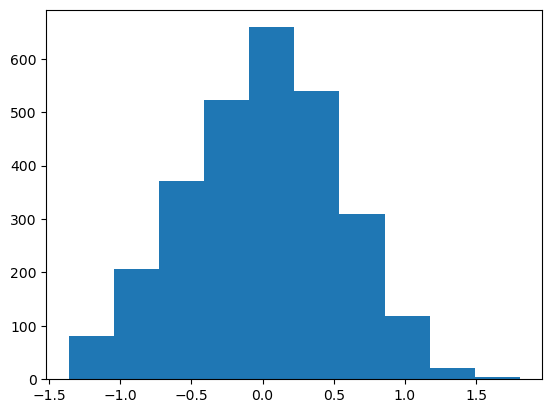

In [10]:
plt.hist(size_factor.squeeze())

In [11]:
perturbations

tensor([2, 0, 0,  ..., 0, 0, 0])

In [12]:
# from networkx import efficiency


efficiency = 0.5
efficiency_probs = torch.tensor([1 - efficiency, efficiency])
dist.Categorical(probs=efficiency_probs).sample((100,))
dist.Categorical(probs=efficiency_probs).log_prob(torch.tensor((0,))).dtype

torch.float32

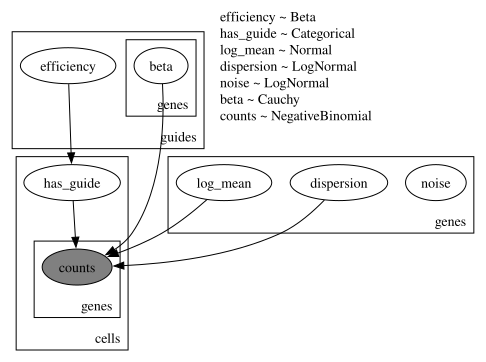

In [19]:
@config_enumerate
def model(
    counts,
    perturbations,
    n_guides=1,
    n_cells=1,
    n_genes=1,
    size_factor=0,
    efficiency=0.8,
    subsample_size = None
):
    guides_plate = pyro.plate("guides", n_guides, dim=-2)
    cells_plate = pyro.plate("cells", n_cells, dim=-2, subsample_size=subsample_size)
    assert isinstance(size_factor, int) or (size_factor.shape == (n_cells, 1))
    with guides_plate:
        efficiency = pyro.sample("efficiency", dist.Beta(9.0, 1.0))
    efficiency = torch.vstack((torch.tensor(0), efficiency))
    # efficiency = torch.full((n_guides + 1,), efficiency)
    with cells_plate as idx:
        perturbations = perturbations[idx]
        efficiency_probs = torch.concatenate(
            [1 - efficiency[perturbations], efficiency[perturbations]], dim=-1
        ).unsqueeze(dim=-2)
        has_guide = pyro.sample("has_guide", dist.Categorical(probs=efficiency_probs, validate_args=True))

    with pyro.plate("genes", n_genes, dim=-1):
        mean = pyro.sample("mean", dist.LogNormal(0.0, 10.0))
        dispersion = pyro.sample("dispersion", dist.LogNormal(3.0, 5.0))
        noise = pyro.sample("noise", dist.LogNormal(3.0, 5.0))

        with guides_plate:
            beta = pyro.sample("beta", dist.Cauchy(0.0, 1.0))
        beta = torch.vstack((torch.zeros(1, n_genes), beta))

        with cells_plate as idx:
            if counts is not None:
                counts = counts[idx, :]
            size_factor = size_factor[idx, :]
            logits = beta[perturbations, :] * has_guide + mean.log() + size_factor
            # obs = pyro.sample("counts", dist.Poisson(logits.exp()), obs=counts)
            obs = pyro.sample(
                "counts",
                dist.NegativeBinomial(total_count=dispersion, logits=logits - dispersion.log()),
                obs=counts,
            )
            # obs = pyro.sample(
            #     "counts",
            #     dist.LogNormalNegativeBinomial(
            #         total_count=dispersion, logits=logits - dispersion.log(), multiplicative_noise_scale=noise
            #     ),
            #     obs=counts,
            # )

    return obs


args = (counts, perturbations)
kwargs = {
    "size_factor": size_factor,
    "n_guides": n_guides,
    "n_cells": n_cells,
    "n_genes": n_genes,
    "efficiency": 0.8,
}
render_model(model, model_args=args, model_kwargs=kwargs, render_distributions=True)
# render_model(model, model_args=(None, perturbations), model_kwargs=kwargs)

In [20]:
# @config_enumerate
# def model(
#     counts,
#     perturbations,
#     n_guides=1,
#     n_cells=1,
#     n_genes=1,
#     size_factor=0,
#     efficiency=0.8,
# ):
#     assert isinstance(size_factor, int) or (size_factor.shape == (n_cells, 1))
#     efficiency_probs = torch.tensor([1 - efficiency, efficiency])
#     with pyro.plate("cells", n_cells, dim=-1):
#         has_guide = pyro.sample("has_guide", dist.Categorical(probs=efficiency_probs, validate_args=True))
#         print(has_guide.shape)
#         # has_guide = pyro.sample("has_guide", dist.Beta(1,1, validate_args=True))
#         # has_guide = 1

#     with pyro.plate("genes", n_genes, dim=-2):
#         log_mean = pyro.sample("log_mean", dist.Normal(0.0, 10.0))
#         with pyro.plate("guides", n_guides + 1, dim=-1):
#             beta = pyro.sample("beta", dist.Cauchy(0.0, 1.0))
#         # return

#         with pyro.plate("cells", dim=-1):
#             logits = beta[:, perturbations] * has_guide + log_mean + size_factor.T
#             obs = pyro.sample("counts", dist.Poisson(logits.exp()), obs=counts.T)

#     return obs


# args = (counts, perturbations)
# kwargs = {"size_factor": size_factor, "n_guides": n_guides, "n_cells": n_cells, "n_genes": n_genes, "efficiency": 0.8}
# render_model(model, model_args=args, model_kwargs=kwargs)
# counts.shape

torch.Size([2830, 5]) torch.int32
torch.Size([2830]) torch.int64
..........

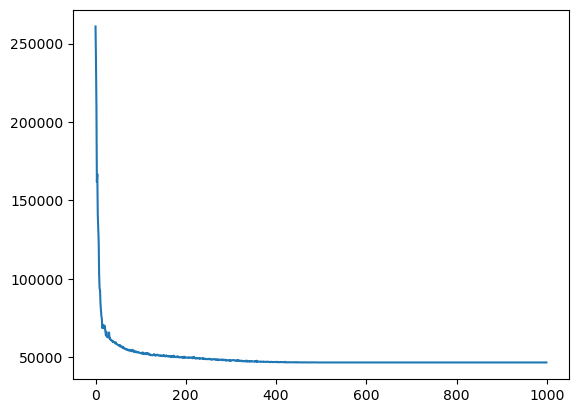

In [15]:
guide = AutoNormal(poutine.block(model, hide=["has_guide", "counts"]))
elbo = TraceEnum_ELBO(max_plate_nesting=2)
optimizer = Adam({"lr": 0.01})
optimizer = Adam({"lr": 0.1})
pyro.clear_param_store()

# args = (None, perturbations)
for a in args:
    if a is not None:
        print(a.shape, a.dtype)
svi = SVI(model, guide, optimizer, loss=elbo)
losses = []
for k in range(1000):
    loss = svi.step(*args, **kwargs)
    losses.append(loss)
    if k % 100 == 0:
        print(".", end="")
        sys.stdout.flush()
plt.plot(losses)

In [16]:
np.log(adata_subset.X.mean(axis=0))

matrix([[2.4181828 , 0.35918048, 2.4054797 , 4.6453857 , 3.227699  ]],
       dtype=float32)

In [17]:
guide.median()

{'efficiency': tensor([[0.8178],
         [0.8860],
         [0.7380],
         [0.6655]]),
 'log_mean': tensor([2.4446, 0.3715, 2.3935, 4.4718, 3.0471]),
 'dispersion': tensor([6.2309, 3.4025, 4.1115, 2.9774, 5.0704]),
 'noise': tensor([20.1278, 25.5966, 16.1090, 26.9875, 50.5865]),
 'beta': tensor([[-2.7324, -2.2799, -2.5197,  0.1723,  0.1439],
         [-3.1583, -1.8188, -2.7264,  0.2540,  0.3038],
         [-3.0838, -1.7847, -2.4889,  0.2296,  0.2564],
         [-0.8497, -0.0294, -0.6678,  0.2128, -0.1291]])}

In [21]:
guide_trace = poutine.trace(guide).get_trace(*args, **kwargs)  # record the globals
trained_model = poutine.replay(model, trace=guide_trace)  # replay the globals
counts_simulated = trained_model(None, perturbations, **kwargs)


# def classifier(args, temperature=0):
#     inferred_model = infer_discrete(
#         trained_model, temperature=temperature, first_available_dim=-3
#     )  # avoid conflict with data plate
#     trace = poutine.trace(inferred_model).get_trace(*args, **kwargs)
#     return trace.nodes["has_guide"]["value"]


# print(classifier(args))

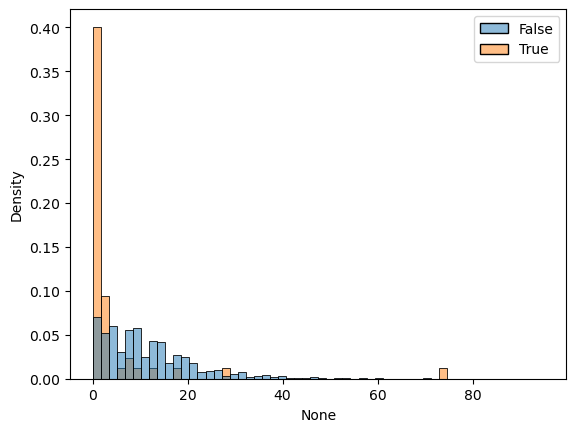

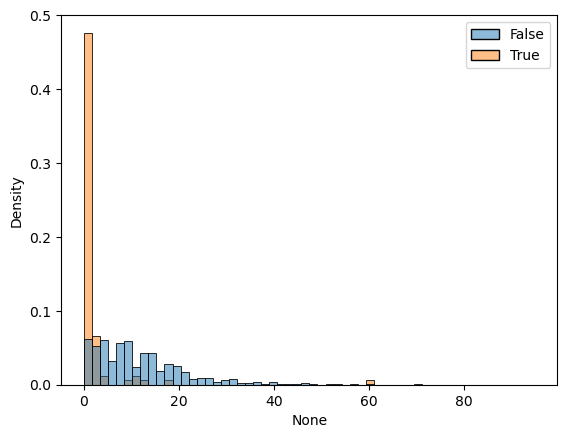

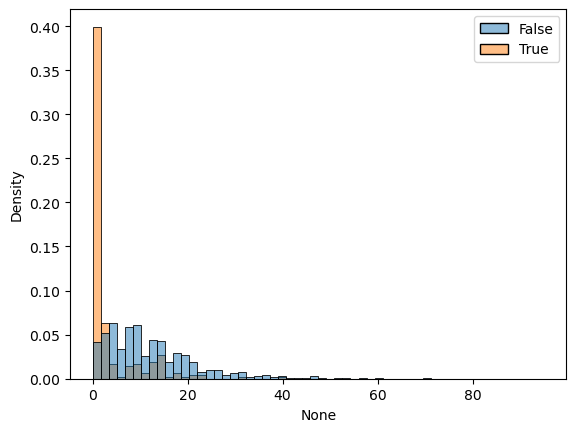

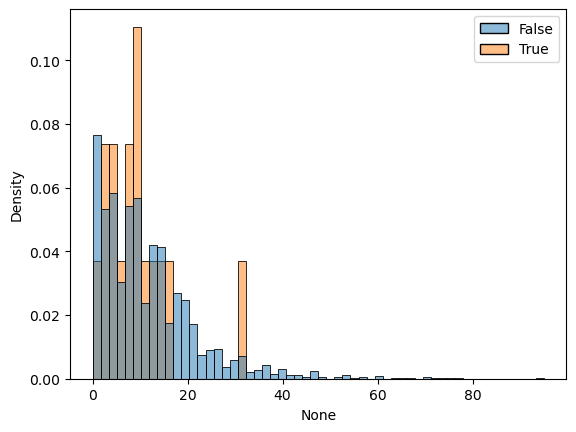

In [22]:
import seaborn as sns

# sns.violinplot(x=adata[:,"STAT1"].X.todense().squeeze(), y=adata.obs["guide_id"].str.contains("STAT1").values.squeeze())
counts_simulated_col = counts_simulated[:, 0]
counts_simulated_col.shape
perts.shape
for i in range(1, 5):
    perts = adata_subset.obs["guide_id"].str.contains(f"STAT1g{i}").values
    sns.histplot(x=counts_simulated_col, hue=perts, common_norm=False, stat="density")
    plt.show()